Running single training curve (state-dependent, N=10, r=3.0, no punishment)...


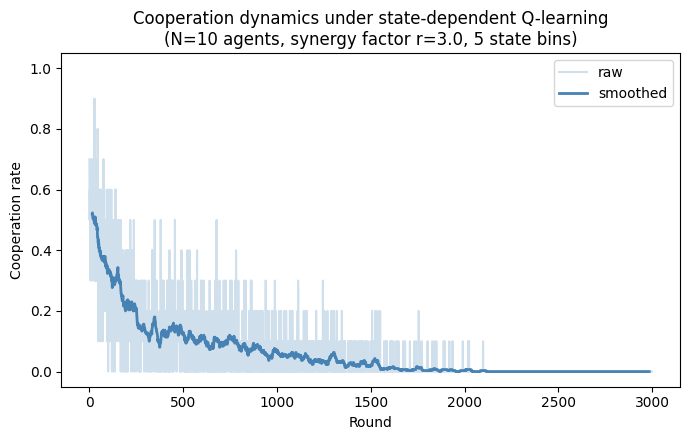

Saved training_curve_stateful.png
Running punishment-strength sweep (state-dependent agents)...


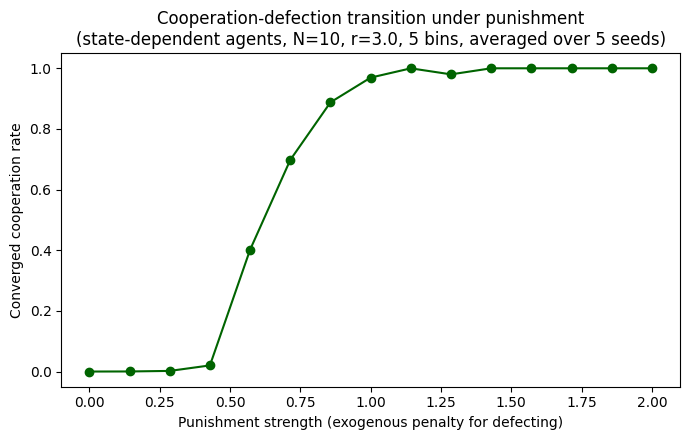

Saved punishment_phase_diagram_stateful.png
Done.


In [1]:

"""
Toy Multi-Agent Reinforcement Learning Simulation -- STATE-DEPENDENT VERSION
=============================================================================

Extension of public_goods_qlearning.py: agents are no longer stateless
bandits. Each agent now conditions its action on a discretized version
of *last round's aggregate cooperation rate*. This turns the model
from N independent bandits relaxing in a fixed potential into agents
whose effective "landscape" changes depending on the observed state of
the group -- a step closer to a genuine coupled many-body system.

"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field


# ----------------------------------------------------------------------
# Environment: N-player Public Goods Game (identical to original)
# ----------------------------------------------------------------------

class PublicGoodsGame:
    """
    N agents each choose an action in {0, 1}: 0 = free-ride (defect),
    1 = contribute (cooperate). Contributions are pooled, multiplied by
    synergy factor r, and split equally among all agents.

    payoff_i = endowment - c*a_i + (r*c*sum(a))/N

    For 1 < r < N: mutual cooperation is Pareto-optimal, but defection
    is individually dominant -- a genuine social dilemma.
    """

    def __init__(self, n_agents: int, synergy_factor: float,
                 endowment: float = 1.0, cost: float = 1.0,
                 punishment_strength: float = 0.0):
        self.n = n_agents
        self.r = synergy_factor
        self.endowment = endowment
        self.c = cost
        self.p = punishment_strength  # exogenous penalty for defecting

    def step(self, actions: np.ndarray) -> np.ndarray:
        total_contribution = self.c * actions.sum()
        share = (self.r * total_contribution) / self.n
        payoffs = self.endowment - self.c * actions + share
        payoffs -= self.p * (1 - actions)  # penalty applied to defectors
        return payoffs


# ----------------------------------------------------------------------
# State discretization
# ----------------------------------------------------------------------

def discretize_coop_rate(coop_rate: float, n_bins: int) -> int:
    """
    Maps a cooperation rate in [0, 1] to a bin index in {0, ..., n_bins-1}.

    E.g. with n_bins=5: bin 0 = [0, 0.2), bin 1 = [0.2, 0.4), ...,
    bin 4 = [0.8, 1.0].
    """
    # edges has n_bins+1 points; digitize gives us the bin index directly
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    # clip handles the coop_rate == 1.0 edge case landing one bin too high
    bin_idx = np.digitize(coop_rate, edges[1:-1])
    return int(np.clip(bin_idx, 0, n_bins - 1))


# ----------------------------------------------------------------------
# Agent: state-dependent tabular Q-learning
# ----------------------------------------------------------------------

@dataclass
class StatefulQLearningAgent:
    """
    Independent Q-learning agent with n_bins discrete states (the
    binned cooperation rate from the previous round) and 2 actions
    {0: defect, 1: cooperate}. Softmax exploration with temperature
    `tau`, applied per-state.

    """

    n_bins: int = 5
    alpha: float = 0.1      # learning rate
    tau: float = 0.5        # exploration temperature
    q: np.ndarray = field(default_factory=lambda: np.zeros((5, 2)))

    def __post_init__(self):
        # rebuild q with the correct shape in case n_bins != 5 was passed
        self.q = np.zeros((self.n_bins, 2))

    def act(self, state: int, rng: np.random.Generator) -> int:
        # softmax over this state's Q-values only
        logits = self.q[state] / max(self.tau, 1e-6)
        logits -= logits.max()  # numerical stability
        probs = np.exp(logits)
        probs /= probs.sum()
        return int(rng.choice([0, 1], p=probs))

    def update(self, state: int, action: int, reward: float):
        # same Q-learning update as before, applied to the row for `state`
        self.q[state, action] += self.alpha * (reward - self.q[state, action])


# ----------------------------------------------------------------------
# Simulation driver
# ----------------------------------------------------------------------

def run_simulation_stateful(n_agents: int, synergy_factor: float,
                             n_rounds: int, n_bins: int = 5,
                             tau: float = 0.5, alpha: float = 0.1,
                             anneal: bool = True, seed: int = 0,
                             punishment_strength: float = 0.0) -> np.ndarray:
    """
    Returns cooperation rate per round, shape (n_rounds,).
    If anneal=True, tau decays toward a floor over training.

    Difference from the previous stateless version: before each round, agents
    look up the Q-row for the bin their group's cooperation rate fell
    into last round, and update that same row after acting.

    """
    rng = np.random.default_rng(seed)
    env = PublicGoodsGame(n_agents, synergy_factor,
                           punishment_strength=punishment_strength)
    agents = [StatefulQLearningAgent(n_bins=n_bins, alpha=alpha, tau=tau)
              for _ in range(n_agents)]

    coop_rate = np.zeros(n_rounds)
    tau_floor = 0.05
    decay = (tau_floor / tau) ** (1.0 / n_rounds) if anneal else 1.0

    # Round 0 has no "previous round" yet -- start in the middle bin,
    # a neutral / uninformative starting state.
    state = n_bins // 2

    for t in range(n_rounds):
        actions = np.array([agent.act(state, rng) for agent in agents])
        payoffs = env.step(actions)

        for agent, a, r in zip(agents, actions, payoffs):
            agent.update(state, a, r)
            if anneal:
                agent.tau = max(agent.tau * decay, tau_floor)

        current_coop_rate = actions.mean()
        coop_rate[t] = current_coop_rate

        # this round's outcome becomes next round's state
        state = discretize_coop_rate(current_coop_rate, n_bins)

    return coop_rate


def sweep_punishment_strength_stateful(n_agents: int, synergy_factor: float,
                                        p_values: np.ndarray, n_rounds: int,
                                        n_bins: int = 5, n_seeds: int = 5,
                                        tau: float = 0.5,
                                        alpha: float = 0.1) -> np.ndarray:
    """
    Same as sweep_punishment_strength, but using
    state-dependent agents. Fixes synergy factor r and sweeps punishment
    strength p, returning converged cooperation rate vs. p.
    """
    tail = max(1, n_rounds // 10)
    results = np.zeros(len(p_values))

    for i, p in enumerate(p_values):
        final_rates = []
        for s in range(n_seeds):
            coop_rate = run_simulation_stateful(
                n_agents, synergy_factor, n_rounds, n_bins=n_bins,
                tau=tau, alpha=alpha, seed=s * 1000 + i,
                punishment_strength=p)
            final_rates.append(coop_rate[-tail:].mean())
        results[i] = np.mean(final_rates)

    return results


# ----------------------------------------------------------------------
# Plotting
# ----------------------------------------------------------------------

def plot_training_curve_stateful(n_agents=10, synergy_factor=3.0,
                                  n_rounds=3000, n_bins=5):
    coop_rate = run_simulation_stateful(n_agents, synergy_factor, n_rounds,
                                         n_bins=n_bins)

    window = max(1, n_rounds // 100)
    smoothed = np.convolve(coop_rate, np.ones(window) / window, mode='valid')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(coop_rate, alpha=0.25, color='steelblue', label='raw')
    ax.plot(np.arange(len(smoothed)) + window / 2, smoothed,
            color='steelblue', linewidth=2, label='smoothed')
    ax.set_xlabel('Round')
    ax.set_ylabel('Cooperation rate')
    ax.set_title(f'Cooperation dynamics under state-dependent Q-learning\n'
                 f'(N={n_agents} agents, synergy factor r={synergy_factor}, '
                 f'{n_bins} state bins)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    fig.tight_layout()
    fig.savefig('training_curve_stateful.png', dpi=300)
    plt.show()
    plt.close(fig)
    print("Saved training_curve_stateful.png")


def plot_punishment_phase_diagram_stateful(n_agents=10, synergy_factor=3.0,
                                            n_rounds=3000, n_bins=5,
                                            n_seeds=5):
    """Cooperation rate vs. punishment strength, state-dependent agents."""
    p_values = np.linspace(0.0, 2.0, 15)
    coop_final = sweep_punishment_strength_stateful(
        n_agents, synergy_factor, p_values, n_rounds,
        n_bins=n_bins, n_seeds=n_seeds)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(p_values, coop_final, 'o-', color='darkgreen')
    ax.set_xlabel('Punishment strength (exogenous penalty for defecting)')
    ax.set_ylabel('Converged cooperation rate')
    ax.set_title(f'Cooperation-defection transition under punishment\n'
                 f'(state-dependent agents, N={n_agents}, r={synergy_factor}, '
                 f'{n_bins} bins, averaged over {n_seeds} seeds)')
    ax.set_ylim(-0.05, 1.05)
    fig.tight_layout()
    fig.savefig('punishment_phase_diagram_stateful.png', dpi=300)
    plt.show()
    plt.close(fig)
    print("Saved punishment_phase_diagram_stateful.png")


if __name__ == '__main__':
    print("Running single training curve (state-dependent, N=10, r=3.0, "
          "no punishment)...")
    plot_training_curve_stateful(n_agents=10, synergy_factor=3.0,
                                  n_rounds=3000, n_bins=5)

    print("Running punishment-strength sweep (state-dependent agents)...")
    plot_punishment_phase_diagram_stateful(n_agents=10, synergy_factor=3.0,
                                            n_rounds=3000, n_bins=5,
                                            n_seeds=5)

    print("Done.")
